# Dementia Disease Progression Prediction
### OASIS Longitudinal MRI Dataset
Predicting dementia progression stage using clinical and brain MRI features across multiple patient visits.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

Download `oasis_longitudinal.csv` from [Kaggle](https://www.kaggle.com/datasets/jboysen/mri-and-alzheimers) and place it in the same folder as this notebook.

In [2]:
df = pd.read_csv('oasis_longitudinal.csv')
print(df.shape)
df.head()

(373, 15)


,Subject ID,MRI ID,Group,Visit,MR Delay,M/F,Hand,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,OAS2_0001,OAS2_0001_MR1,Nondemented,1,0,M,R,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,OAS2_0001,OAS2_0001_MR2,Nondemented,2,457,M,R,88,14,2.0,30.0,0.0,2004,0.681,0.876
2,OAS2_0002,OAS2_0002_MR1,Demented,1,0,M,R,75,12,NaN,23.0,0.5,1678,0.736,1.046
3,OAS2_0002,OAS2_0002_MR2,Demented,2,560,M,R,76,12,NaN,28.0,0.5,1738,0.713,1.010
4,OAS2_0002,OAS2_0002_MR3,Demented,3,1895,M,R,80,12,NaN,22.0,0.5,1698,0.701,1.034


In [3]:
# check for missing values
df.isnull().sum()

Subject ID     0
MRI ID         0
Group          0
Visit          0
MR Delay       0
M/F            0
Hand           0
Age            0
EDUC           0
SES           19
MMSE           2
CDR            0
eTIV           0
nWBV           0
ASF            0
dtype: int64

In [4]:
# basic stats
df.describe()

,Visit,MR Delay,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
count,373.000000,373.000000,373.000000,373.000000,354.000000,371.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.460452,27.342318,0.290885,1488.128686,0.729568,1.195461
std,0.922843,635.485118,7.640957,2.876339,1.134005,3.683244,0.374557,176.139286,0.037135,0.138092
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.000000,0.700000,1.099000
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.000000,0.729000,1.194000
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1597.000000,0.756000,1.293000
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.000000,0.837000,1.587000


## 3. Create 3-Stage Progression Labels

We use 3 clinically meaningful stages based on CDR score:
- **0 = No Dementia** — CDR = 0
- **1 = Very Mild** — CDR = 0.5
- **2 = Dementia** — CDR >= 1.0 (Mild and Moderate combined)

Mild and Moderate are combined because the OASIS dataset has very few Moderate cases which is not enough for the model to learn from separately.

In [5]:
def get_stage(row):
    if row['CDR'] == 0:
        return 0  # No Dementia
    elif row['CDR'] == 0.5:
        return 1  # Very Mild
    else:
        return 2  # Dementia (Mild + Moderate)

stage_labels = {0: 'No Dementia', 1: 'Very Mild', 2: 'Dementia'}
colors = ['#4ecdc4', '#ffd93d', '#ff6b35']

df = df.dropna(subset=['CDR'])
df['Stage'] = df.apply(get_stage, axis=1)

print('Stage distribution:')
print(df['Stage'].value_counts().sort_index())

Stage distribution:
Stage
0    206
1    123
2     44
Name: count, dtype: int64


## 4. Exploratory Data Analysis

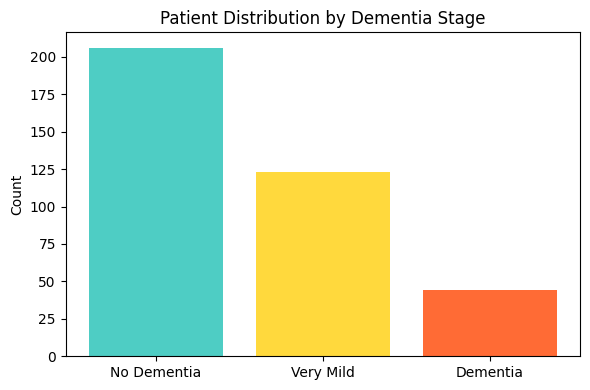

In [6]:
# stage distribution
counts = df['Stage'].value_counts().sort_index()
stage_names = [stage_labels[i] for i in counts.index]

plt.figure(figsize=(6, 4))
plt.bar(stage_names, counts.values, color=colors, edgecolor='none')
plt.title('Patient Distribution by Dementia Stage')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

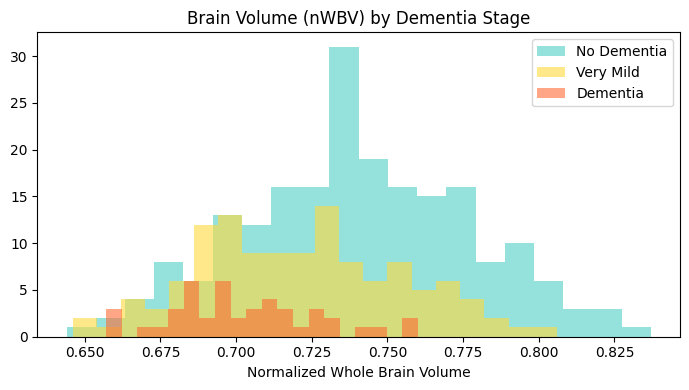

In [7]:
# brain volume by stage
plt.figure(figsize=(7, 4))
for stage, color in zip([0, 1, 2], colors):
    subset = df[df['Stage'] == stage]['nWBV']
    plt.hist(subset, bins=20, alpha=0.6, color=color, label=stage_labels[stage])

plt.title('Brain Volume (nWBV) by Dementia Stage')
plt.xlabel('Normalized Whole Brain Volume')
plt.legend()
plt.tight_layout()
plt.show()

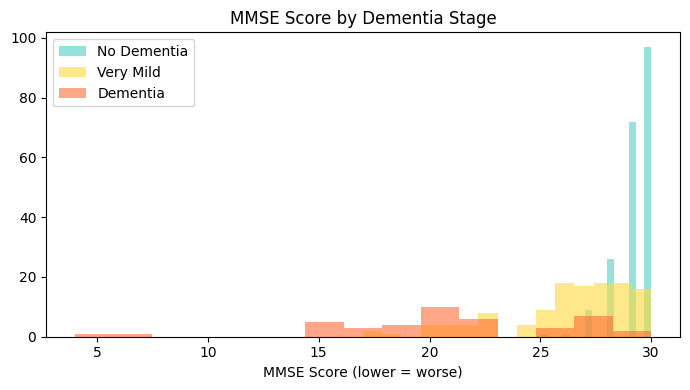

In [8]:
# MMSE score by stage
plt.figure(figsize=(7, 4))
df_clean = df.dropna(subset=['MMSE'])
for stage, color in zip([0, 1, 2], colors):
    subset = df_clean[df_clean['Stage'] == stage]['MMSE']
    plt.hist(subset, bins=15, alpha=0.6, color=color, label=stage_labels[stage])

plt.title('MMSE Score by Dementia Stage')
plt.xlabel('MMSE Score (lower = worse)')
plt.legend()
plt.tight_layout()
plt.show()

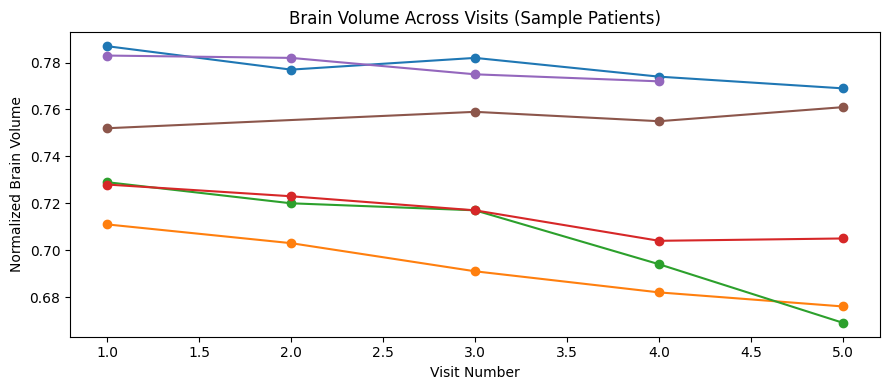

In [9]:
# brain volume across visits for same patients
sample_patients = df['Subject ID'].value_counts()[
    df['Subject ID'].value_counts() >= 3].index[:6]

plt.figure(figsize=(9, 4))
for pid in sample_patients:
    patient_data = df[df['Subject ID'] == pid].sort_values('Visit')
    plt.plot(patient_data['Visit'], patient_data['nWBV'], marker='o', linewidth=1.5)

plt.title('Brain Volume Across Visits (Sample Patients)')
plt.xlabel('Visit Number')
plt.ylabel('Normalized Brain Volume')
plt.tight_layout()
plt.show()

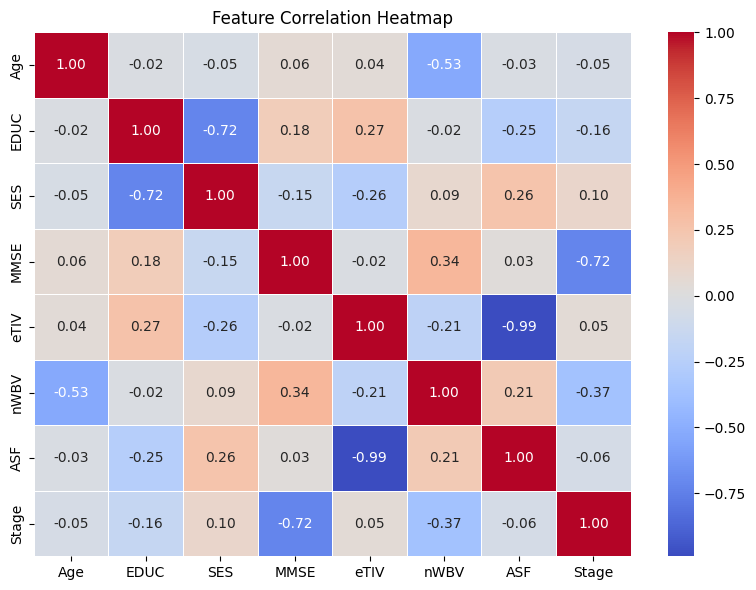

In [10]:
# correlation heatmap
num_cols = ['Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'Stage']
df_corr = df[num_cols].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Balance the Dataset

In [11]:
# balance classes by oversampling minority stages
df_majority = df[df['Stage'] == 1]  # Very Mild is largest class
df_min0 = resample(df[df['Stage'] == 0], replace=True,
                   n_samples=len(df_majority), random_state=42)
df_min2 = resample(df[df['Stage'] == 2], replace=True,
                   n_samples=len(df_majority), random_state=42)

df_balanced = pd.concat([df_majority, df_min0, df_min2])
print('Balanced stage distribution:')
print(df_balanced['Stage'].value_counts().sort_index())

Balanced stage distribution:
Stage
0    123
1    123
2    123
Name: count, dtype: int64


## 6. Preprocessing

In [12]:
# encode gender
df_balanced = df_balanced.copy()
df_balanced['M/F'] = LabelEncoder().fit_transform(df_balanced['M/F'].astype(str))

# select features
features = ['Visit', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF', 'M/F']

# fill missing values with median
for col in features:
    df_balanced[col] = df_balanced[col].fillna(df_balanced[col].median())

X = df_balanced[features]
y = df_balanced['Stage']

# split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 295 samples | Test: 74 samples


## 7. Train XGBoost Model

In [13]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [14]:
# predictions
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Test Accuracy: {acc:.4f}')

Test Accuracy: 0.8243


## 8. Evaluation

In [15]:
print(classification_report(y_test, y_pred,
      target_names=['No Dementia', 'Very Mild', 'Dementia']))

              precision    recall  f1-score   support

 No Dementia       0.84      0.88      0.86        24
   Very Mild       0.83      0.60      0.70        25
    Dementia       0.81      1.00      0.89        25

    accuracy                           0.82        74
   macro avg       0.83      0.83      0.82        74
weighted avg       0.83      0.82      0.82        74



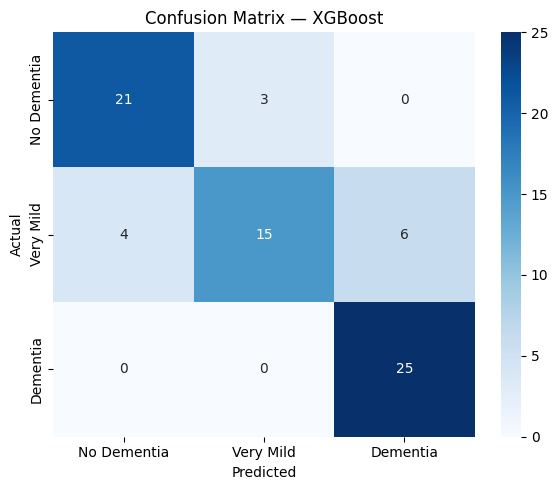

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Dementia', 'Very Mild', 'Dementia'],
            yticklabels=['No Dementia', 'Very Mild', 'Dementia'])
plt.title('Confusion Matrix — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. Feature Importance

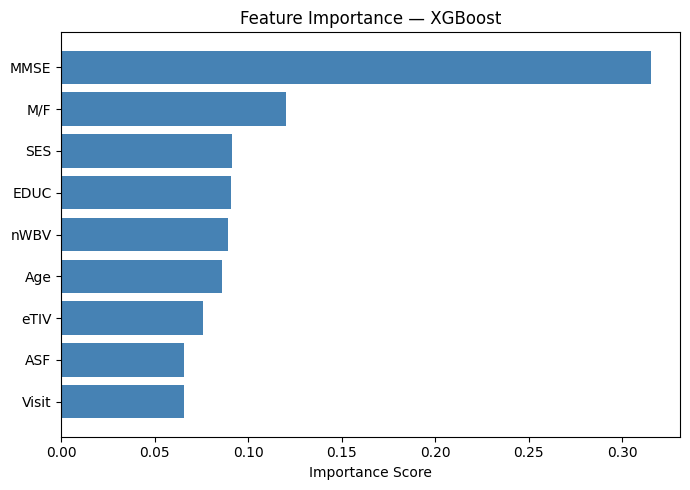

In [17]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(7, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 10. Progression Simulation Function

Takes a patient's baseline readings and simulates how their condition might progress over future visits if untreated.

In [18]:
def simulate_progression(base_patient, visits=5):
    records = []
    patient = base_patient.copy()

    for visit in range(1, visits + 1):
        patient['Visit'] = visit
        patient['nWBV'] = round(patient['nWBV'] - 0.004 * visit, 4)
        patient['MMSE'] = max(0, patient['MMSE'] - 1.0 * visit)

        input_df = pd.DataFrame([patient])[features]
        stage_pred = model.predict(input_df)[0]
        probs = model.predict_proba(input_df)[0]

        records.append({
            'Visit': visit,
            'nWBV': patient['nWBV'],
            'MMSE': round(patient['MMSE'], 1),
            'Predicted Stage': stage_labels[stage_pred],
            'Confidence': f'{max(probs)*100:.1f}%'
        })

    return pd.DataFrame(records)

## 11. Predict for a New Patient

--- Current Stage ---
Predicted Stage  : Very Mild
P(No Dementia)   : 2.5%
P(Very Mild)     : 86.3%
P(Dementia)      : 11.2%

--- Progression Over Next 5 Visits ---
 Visit  nWBV  MMSE Predicted Stage Confidence
     1 0.736  25.0       Very Mild      84.0%
     2 0.728  23.0        Dementia      91.4%
     3 0.716  20.0        Dementia      99.4%
     4 0.700  16.0        Dementia      99.3%
     5 0.680  11.0        Dementia      99.3%


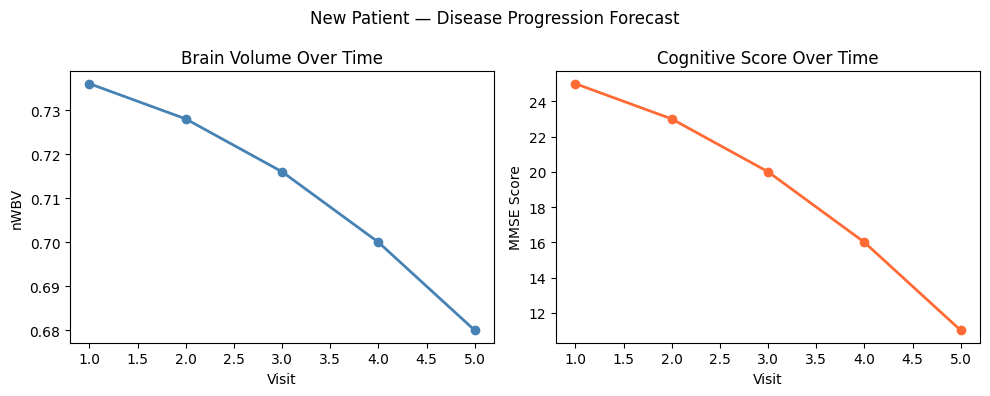

In [19]:
# change these values to test different patients
new_patient_base = {
    'Visit': 1,
    'Age': 75,
    'EDUC': 12,
    'SES': 2,
    'MMSE': 26,
    'eTIV': 1480,
    'nWBV': 0.74,
    'ASF': 1.15,
    'M/F': 0
}

# current stage
new_patient_df = pd.DataFrame([new_patient_base])[features]
prediction = model.predict(new_patient_df)[0]
probabilities = model.predict_proba(new_patient_df)[0]

print('--- Current Stage ---')
print(f'Predicted Stage  : {stage_labels[prediction]}')
print(f'P(No Dementia)   : {probabilities[0]*100:.1f}%')
print(f'P(Very Mild)     : {probabilities[1]*100:.1f}%')
print(f'P(Dementia)      : {probabilities[2]*100:.1f}%')

# future progression
print('\n--- Progression Over Next 5 Visits ---')
new_progression = simulate_progression(new_patient_base, visits=5)
print(new_progression.to_string(index=False))

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(new_progression['Visit'], new_progression['nWBV'],
             marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Brain Volume Over Time')
axes[0].set_xlabel('Visit')
axes[0].set_ylabel('nWBV')

axes[1].plot(new_progression['Visit'], new_progression['MMSE'],
             marker='o', color='#ff6b35', linewidth=2)
axes[1].set_title('Cognitive Score Over Time')
axes[1].set_xlabel('Visit')
axes[1].set_ylabel('MMSE Score')

plt.suptitle('New Patient — Disease Progression Forecast', fontsize=12)
plt.tight_layout()
plt.show()

In [20]:
def generate_clinical_summary(progression_df, current_stage, probabilities):
    
    start_stage = progression_df.iloc[0]['Predicted Stage']
    end_stage = progression_df.iloc[-1]['Predicted Stage']
    start_mmse = progression_df.iloc[0]['MMSE']
    end_mmse = progression_df.iloc[-1]['MMSE']
    start_nwbv = progression_df.iloc[0]['nWBV']
    end_nwbv = progression_df.iloc[-1]['nWBV']
    total_visits = len(progression_df)

    stage_change_visit = None
    for i, row in progression_df.iterrows():
        if row['Predicted Stage'] != start_stage:
            stage_change_visit = row['Visit']
            break

    summary = f"The patient is currently classified as {current_stage} "
    summary += f"with {max(probabilities)*100:.1f}% model confidence. "

    if stage_change_visit:
        summary += f"Progression simulation shows the condition advancing from {start_stage} "
        summary += f"to {end_stage} by Visit {stage_change_visit}. "
    else:
        summary += f"The model predicts the patient remains at {current_stage} "
        summary += f"across all {total_visits} simulated visits. "

    summary += f"Brain volume declines from {start_nwbv} to {end_nwbv} "
    summary += f"and cognitive score drops from {start_mmse} to {end_mmse}, "
    summary += f"indicating progressive neurodegeneration over time."

    return summary

summary = generate_clinical_summary(new_progression, stage_labels[prediction], probabilities)
print("--- Clinical Summary ---")
print(summary)

--- Clinical Summary ---
The patient is currently classified as Very Mild with 86.3% model confidence. Progression simulation shows the condition advancing from Very Mild to Dementia by Visit 2. Brain volume declines from 0.736 to 0.68 and cognitive score drops from 25.0 to 11.0, indicating progressive neurodegeneration over time.
